In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import backend as K
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.sequence import pad_sequences

import jiwer

In [3]:
BATCH_SIZE = 32
NUM_EPOCHS = 80

COLS_IMG = 256
ROWS_IMG = 64

In [4]:
from datasets import load_dataset

ds = load_dataset("Teklia/IAM-line")

/Users/chvicencio/Desktop/Projects/FreehandToText/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
print(ds)

# get training data
validation_dataset = ds['validation']
test_dataset = ds['test']
train_dataset = ds['train']

x_train, y_train            = [], []
x_test, y_test              = [], []
x_validation, y_validation  = [], []

for data in train_dataset:
    img = data['image'].resize((COLS_IMG, ROWS_IMG))
    txt = data['text']
    x_train.append(np.array(img))
    y_train.append(txt)

for data in test_dataset:
    img = data['image'].resize((COLS_IMG, ROWS_IMG))
    txt = data['text']
    x_test.append(np.array(img))
    y_test.append(txt)

for data in validation_dataset:
    img = data['image'].resize((COLS_IMG, ROWS_IMG))
    txt = data['text']
    x_validation.append(np.array(img))
    y_validation.append(txt)


x_train = np.array(x_train)
y_train = np.array(y_train)

x_test  = np.array(x_test)
y_test  = np.array(y_test)

x_validation = np.array(x_validation)
y_validation = np.array(y_validation)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)
print(x_validation.shape, y_validation.shape)


DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 6482
    })
    validation: Dataset({
        features: ['image', 'text'],
        num_rows: 976
    })
    test: Dataset({
        features: ['image', 'text'],
        num_rows: 2915
    })
})
(6482, 64, 256) (6482,)
(2915, 64, 256) (2915,)
(976, 64, 256) (976,)


In [6]:
# Reshape to 4D
x_train = x_train.reshape(x_train.shape[0], ROWS_IMG, COLS_IMG, 1)
x_test = x_test.reshape(x_test.shape[0], ROWS_IMG, COLS_IMG, 1)
x_validation = x_validation.reshape(x_validation.shape[0], ROWS_IMG, COLS_IMG, 1)

# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_validation = x_validation.astype("float32") / 255.0


# Text: keep as lists, don't convert to numpy yet
# y_train, y_test, y_validation are still lists of strings

In [7]:
# Create character vocabulary
chars = set()
# Convert numpy arrays back to lists for concatenation
y_train_list = y_train.tolist()
y_test_list = y_test.tolist()
y_validation_list = y_validation.tolist()

for text in y_train_list + y_test_list + y_validation_list:
    chars.update(text)

chars = sorted(list(chars))
char_to_int = {char: i for i, char in enumerate(chars)}
int_to_char = {i: char for i, char in enumerate(chars)}

# Encode text to integers
def encode_text(text):
    return [char_to_int[char] for char in text]

# Encode all text data using the list versions
y_train_encoded = [encode_text(text) for text in y_train_list]
y_test_encoded = [encode_text(text) for text in y_test_list]
y_validation_encoded = [encode_text(text) for text in y_validation_list]

num_classes = len(chars) + 1  # +1 for CTC blank token
print(f"Vocabulary size: {num_classes}")
print(f"{chars}")

Vocabulary size: 80
[' ', '!', '"', '#', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [8]:
# Input shape: (batch_size, height, width, channels)
input_shape = (ROWS_IMG, COLS_IMG, 1)
inputs = tf.keras.Input(shape=input_shape)

# CNN feature extractor
x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2, 1), strides=(2, 1))(x)
x = layers.Dropout(0.10)(x)

x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2, 1), strides=(2, 1))(x)
x = layers.Dropout(0.15)(x)

x = layers.Conv2D(256, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2, 1), strides=(2, 1))(x)
x = layers.Dropout(0.25)(x)

x = layers.Conv2D(512, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2, 1), strides=(2, 1))(x)
x = layers.Dropout(0.25)(x)

'''

x = layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(1e-5))(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2, 1), strides=(2, 1))(x)

x = layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.0001))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2, 1), strides=(2, 1))(x)

x = layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.0001))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2, 1), strides=(2, 1))(x)

x = layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2, 1), strides=(2, 1))(x)
'''

# Reshape CNN output
features = layers.Reshape((256, 4*512))(x)

# Projection layer, apply features to each time step
# features = layers.TimeDistributed(layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(0.001)))(features)
features = layers.TimeDistributed(layers.Dense(1024, activation="relu"))(features)
features = layers.BatchNormalization()(features)
features = layers.Dropout(0.30)(features)
# BiLSTM layer
lstm_out = layers.Bidirectional(layers.LSTM(256, return_sequences=True, dropout=0.10))(features)
lstm_out = layers.Bidirectional(layers.LSTM(256, return_sequences=True, dropout=0.15))(lstm_out)

outputs = layers.Dense(num_classes, activation="linear")(lstm_out)

# Define the model
model = models.Model(inputs, outputs)
model.summary()
# model.load_weights(os.path.join(drive_path, "new_weights_model_27val_12tra.weights.h5"))

# Calculate the maximum label length across all datasets
max_label_len = max([len(seq) for seq in y_train_encoded + y_test_encoded + y_validation_encoded])
print(f"Max label len :: {max_label_len}")

# Fix the padding value - use 0 instead of -1 for CTC
padded_value = num_classes-1
y_train_padded =      pad_sequences(y_train_encoded, maxlen=max_label_len, padding='post', value=padded_value)
y_test_padded =       pad_sequences(y_test_encoded, maxlen=max_label_len, padding='post', value=padded_value)
y_validation_padded = pad_sequences(y_validation_encoded, maxlen=max_label_len, padding='post', value=padded_value)

# Better CTC loss function that handles variable-length sequences
@tf.keras.utils.register_keras_serializable()
def ctc_loss_func(y_true, y_pred):
    batch_len    = tf.cast(tf.shape(y_true)[0], dtype="int64")
    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")

    label_length = tf.reduce_sum(tf.cast(y_true != (num_classes - 1), dtype="int64"), axis=1)

    input_length = input_length * tf.ones(shape=(batch_len,), dtype="int64")

    # Remove padding from y_true for CTC
    y_true_sparse = tf.cast(y_true, dtype="int32")

    return tf.reduce_mean(tf.nn.ctc_loss(
        logits_time_major=False,
        logits=y_pred,
        labels=y_true_sparse,
        label_length=label_length,
        logit_length=input_length,
        blank_index=num_classes-1  # Use last class as blank

    ))

# Alternative simpler approach - use built-in CTC loss
opt = tf.keras.optimizers.AdamW(
    # learning_rate=5e-4,#1e-3,
    learning_rate=1e-3,
    weight_decay=1e-4,
    clipnorm=5.0
)

model.compile(
    optimizer=opt,
    # optimizer=tf.keras.optimizers.SGD(learning_rate=5e-4, momentum=0.9, nesterov=True), # use after learning_rate=5e-4,  # start smaller, AdamW already moved far
    loss=ctc_loss_func,
)


# ******** MODEL FILE NAMES ***************
model_weight_file = 'final_weights_AdamW.weights.h5'
full_model_file = 'handwriting_model_full_AdamW.keras'

checkpoint_weights_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=model_weight_file,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,   # only weights, fast
    verbose=1
)

checkpoint_full_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=full_model_file,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,  # full model (architecture + optimizer + loss)
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',          # Monitor validation loss
    factor=0.5,                  # Reduce LR by half
    patience=4,                  # Wait x epochs before reducing
    min_lr=1e-7,                 # Minimum learning rate
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,                  # Stop if no improvement for x epochs
    restore_best_weights=True,
    verbose=1
)

'''
history = model.fit(x_train, y_train_padded,
                    epochs=NUM_EPOCHS,
                    validation_data=(x_validation, y_validation_padded),
                    callbacks=[reduce_lr, early_stopping, checkpoint_full_cb, checkpoint_weights_cb],
                    shuffle=True,
)
'''

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 256, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 256, 64)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 256, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 256, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 256, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 256, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 256, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 256, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 256, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 256, 256)   │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 256, 256)   │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 256, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 256, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 256, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 256, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 256, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 256, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 256, 2048)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 256, 1024)      │     2,098,176 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256, 1024)      │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256, 1024)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256, 512)       │     2,623,48

 Total params: 7,895,376 (30.12 MB)

 Trainable params: 7,891,408 (30.10 MB)

 Non-trainable params: 3,968 (15.50 KB)

Max label len :: 93


'\nhistory = model.fit(x_train, y_train_padded,\n                    epochs=NUM_EPOCHS,\n                    validation_data=(x_validation, y_validation_padded),\n                    callbacks=[reduce_lr, early_stopping, checkpoint_full_cb, checkpoint_weights_cb],\n                    shuffle=True,\n)\n'

In [9]:
model = tf.keras.models.load_model("./TrainedModels/new_full_model_27val_12tra.keras", compile=False)

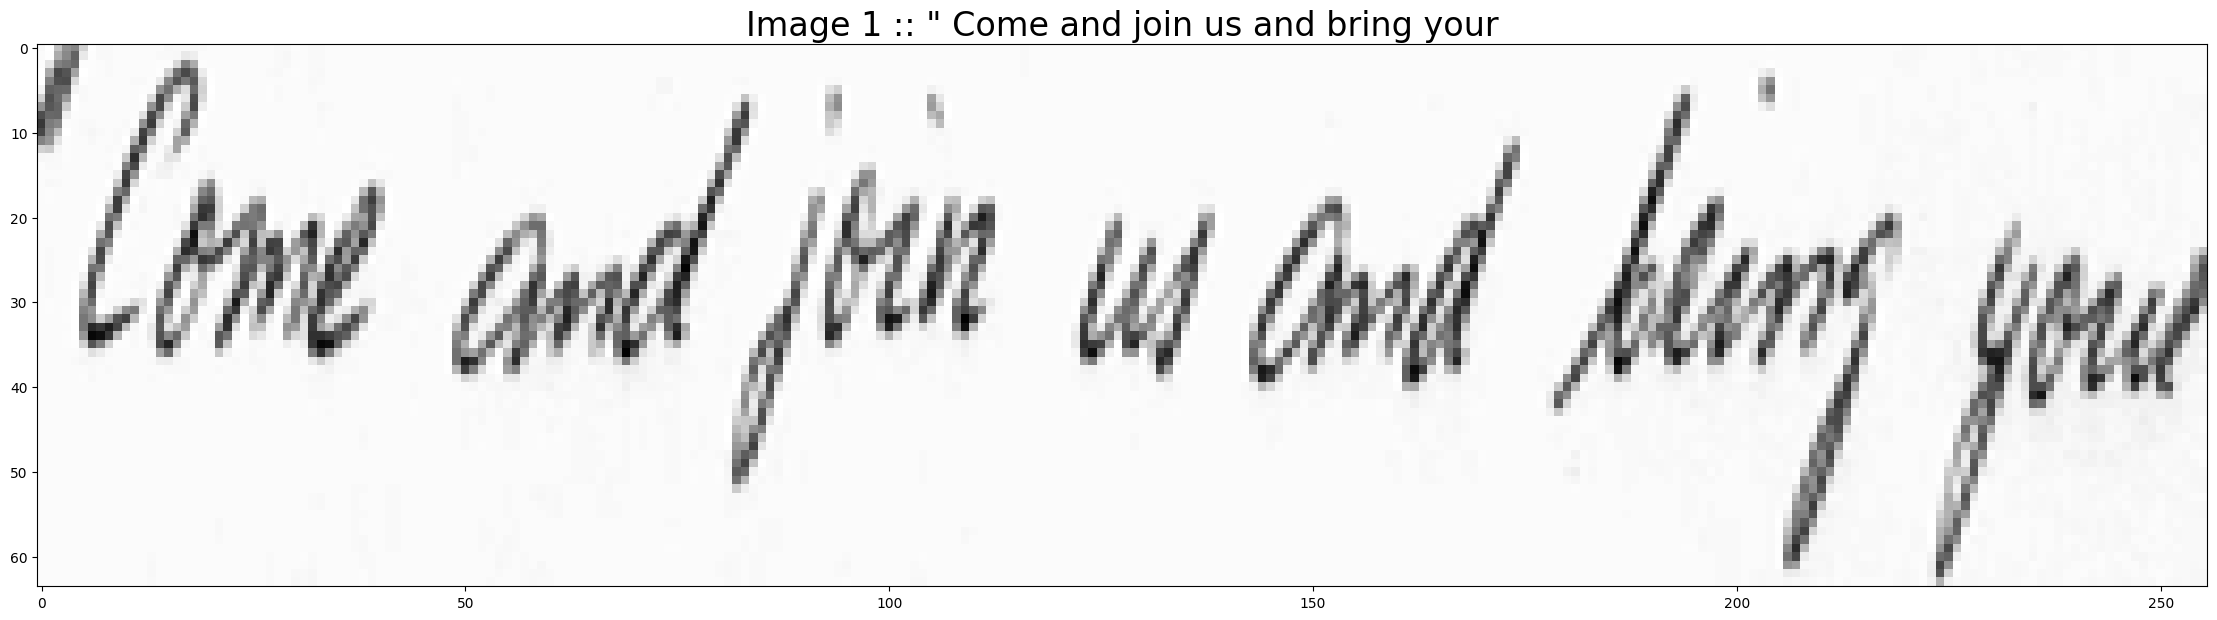

In [10]:
# Plot the Image
DUMMY_BATCH_SIZE = 1
image_index = np.random.randint(0, x_test.shape[0], size=DUMMY_BATCH_SIZE)
dummy_batch = x_test[image_index]
true_labels = y_test[image_index]

fig, axes = plt.subplots(1, DUMMY_BATCH_SIZE, figsize=(28, 28))

# if batch = 1
if DUMMY_BATCH_SIZE == 1:
    axes = [axes]  # Make it iterable

for i in range(DUMMY_BATCH_SIZE):
    axes[i].imshow(dummy_batch[i], cmap='gray')
    axes[i].set_title(f"Image {i+1} :: {true_labels[i]}", fontsize=24)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
CNN features shape: (1, 4, 256, 512)


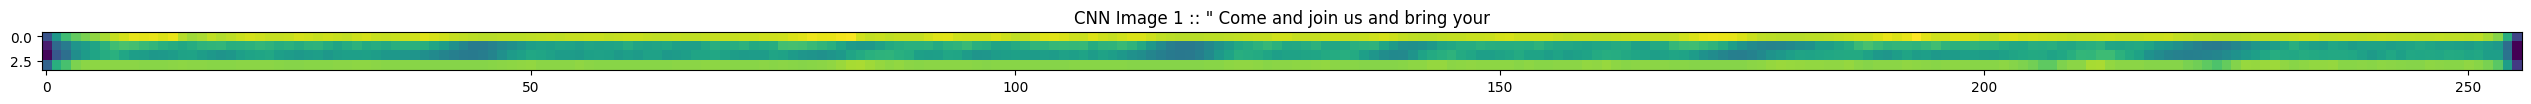

In [11]:
TEST_IMG_ROW = 32
TEST_IMG_COL = 8

# Get CNN features for dummy_images
# cnn_model = models.Model(inputs, features)
cnn_model = models.Model(inputs, x)
cnn_features = cnn_model.predict(dummy_batch)

print("CNN features shape:", cnn_features.shape)
fig, axes = plt.subplots(1, DUMMY_BATCH_SIZE, figsize=(TEST_IMG_ROW, TEST_IMG_COL))

# if batch = 1
if DUMMY_BATCH_SIZE == 1:
    axes = [axes]  # Make it iterable

for i in range(DUMMY_BATCH_SIZE):
    # Show the mean across channels for visualization
    axes[i].imshow(np.mean(cnn_features[i], axis=-1), cmap='viridis')
    # axes[i].imshow(cnn_features[i], aspect='auto', cmap='viridis')
    axes[i].set_title(f"CNN Image {i+1} :: {true_labels[i]}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
BiLSTM features shape: (1, 256, 512)


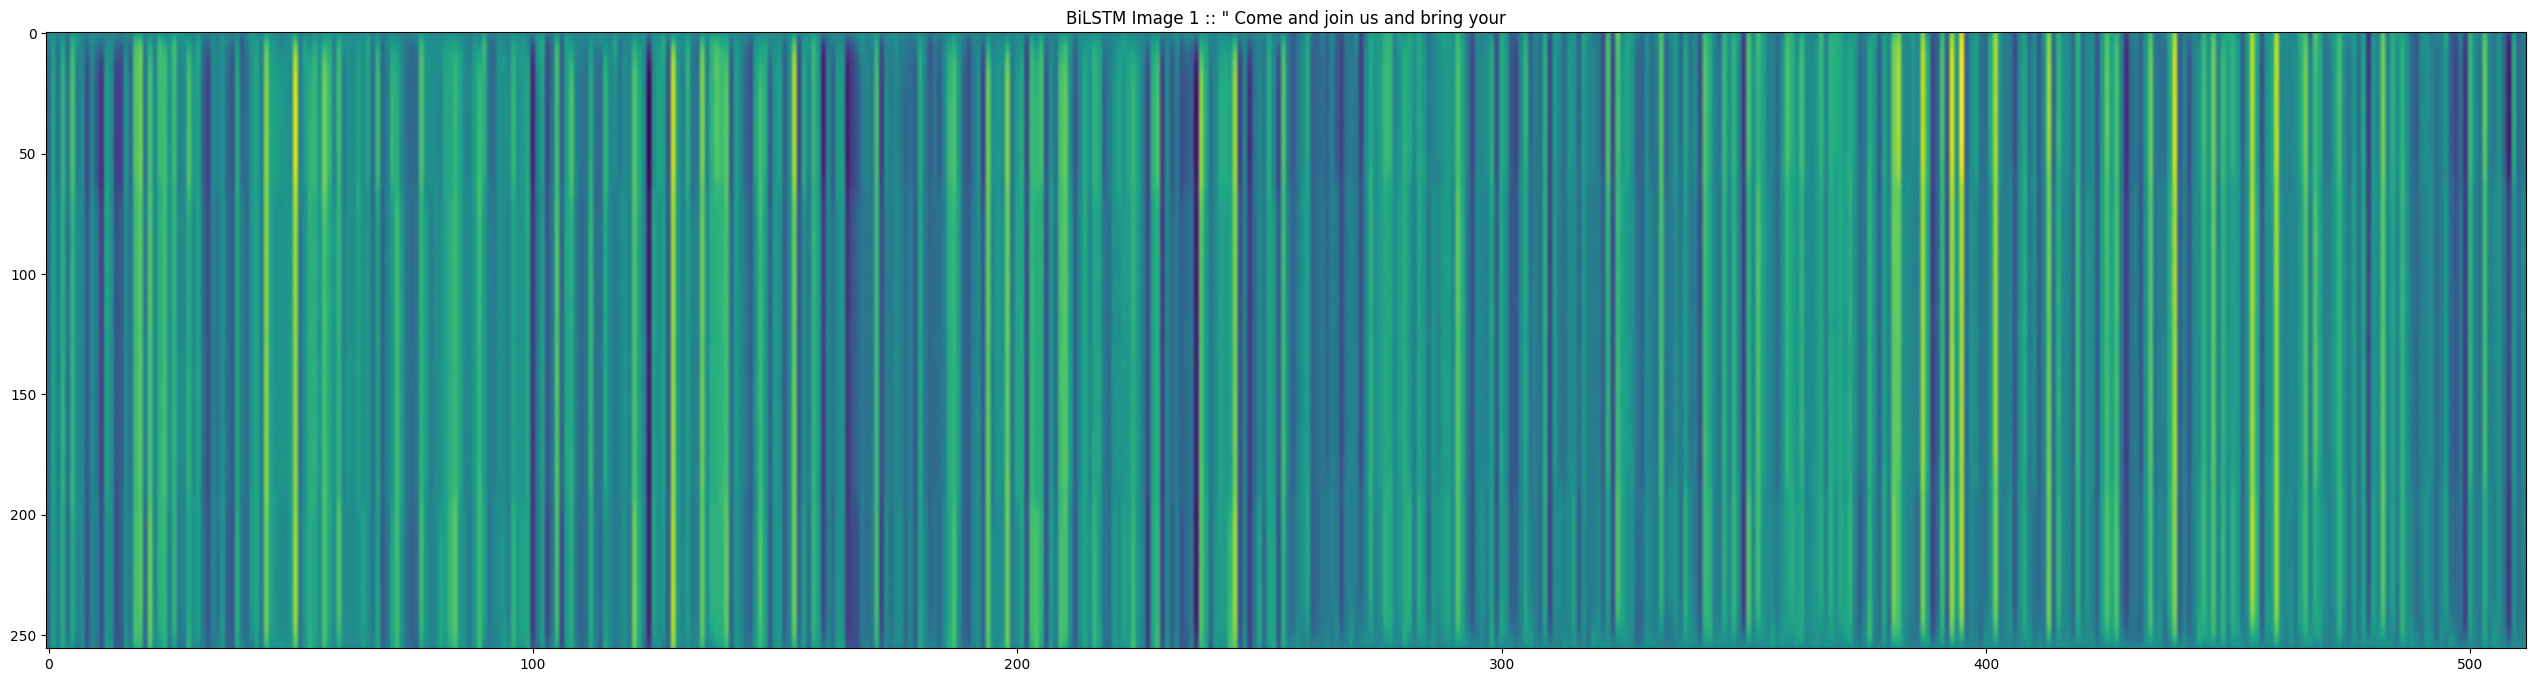

In [12]:
biLSTM = models.Model(inputs, lstm_out)
biLSTM_features = biLSTM.predict(dummy_batch)

print("BiLSTM features shape:", biLSTM_features.shape)
fig, axes = plt.subplots(1, DUMMY_BATCH_SIZE, figsize=(TEST_IMG_ROW, TEST_IMG_COL))

if DUMMY_BATCH_SIZE == 1:
    axes = [axes]  # Make it iterable

for i in range(DUMMY_BATCH_SIZE):
    # Show the BiLSTM output as a heatmap: shape (7, 11)
    axes[i].imshow(biLSTM_features[i], aspect='auto', cmap='viridis')
    axes[i].set_title(f"BiLSTM Image {i+1} :: {true_labels[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Full output shape: (1, 256, 80)


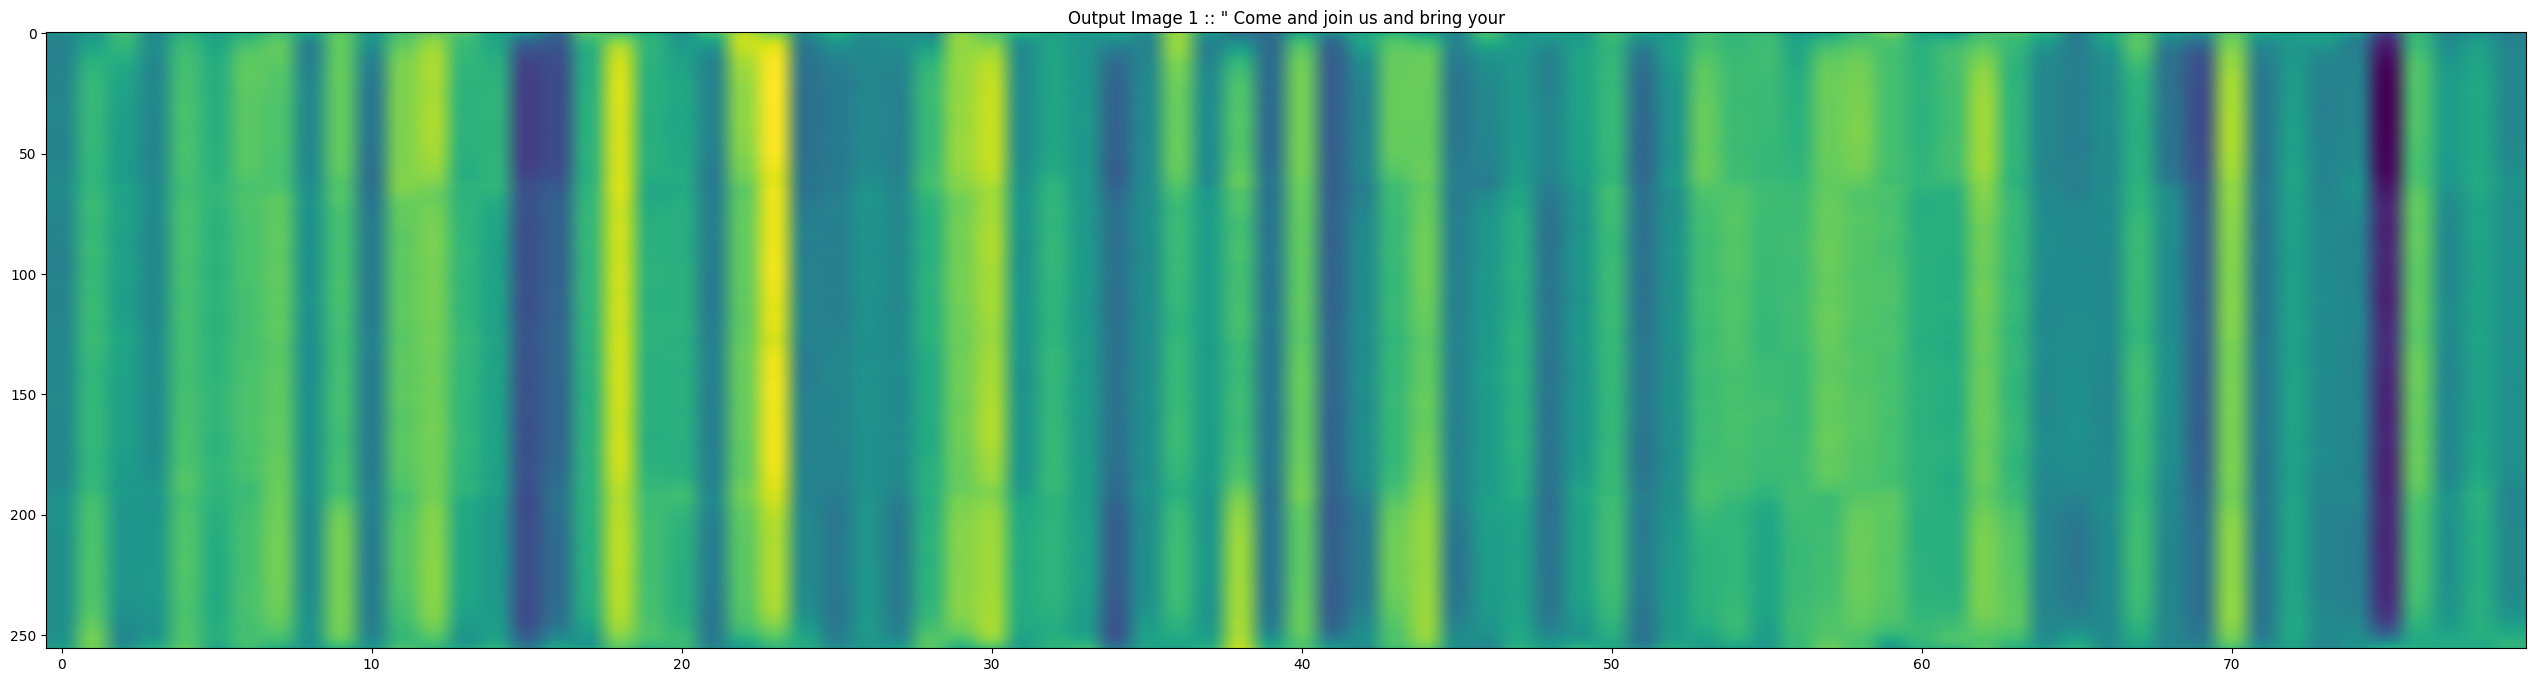

In [13]:
output_model = models.Model(inputs, outputs)
output_features = output_model.predict(dummy_batch)

print("Full output shape:", output_features.shape)
fig, axes = plt.subplots(1, DUMMY_BATCH_SIZE, figsize=(TEST_IMG_ROW, TEST_IMG_COL))

if DUMMY_BATCH_SIZE == 1:
    axes = [axes]  # Make it iterable

for i in range(DUMMY_BATCH_SIZE):
    axes[i].imshow(output_features[i], aspect='auto', cmap='viridis')
    axes[i].set_title(f"Output Image {i+1} :: {true_labels[i]}")

In [14]:
def get_decoded_texts(raw_predictions: np.ndarray) -> list[str]:
    """Converts raw model predictions to decoded text strings."""
    raw_preds_tensor = tf.convert_to_tensor(raw_predictions, dtype=tf.float32)
    batch_size = tf.shape(raw_preds_tensor)[0]

    # Transpose and convert to log probabilities for CTC
    transposed_preds = tf.transpose(raw_preds_tensor, perm=[1, 0, 2])
    input_length = tf.fill([batch_size], tf.shape(raw_preds_tensor)[1])

    # Decode
    decoded_preds, _ = tf.nn.ctc_beam_search_decoder(transposed_preds, input_length, beam_width=10, top_paths=1)
    decoded_preds_dense = tf.sparse.to_dense(decoded_preds[0], default_value=-1)

    # Convert predictions to text
    def decode_prediction(preds):
        return ''.join(int_to_char[p] for p in preds if p != -1 and p != (len(int_to_char)-1))

    predictions_text = [decode_prediction(seq.numpy().tolist()) for seq in decoded_preds_dense]
    return predictions_text


def calculate_mean_cer(true_preds: list[str], preds: list[str]) -> float:
    if len(true_preds)==0 or len(preds)==0:
        return 0.0
    min_len = min(len(true_preds), len(preds))
    return jiwer.cer(true_preds[:min_len], preds[:min_len])


def calculate_mean_wer(true_preds: list[str], preds: list[str]) -> float:
    if len(true_preds)==0 or len(preds)==0:
        return 0.0
    min_len = min(len(true_preds), len(preds))
    return jiwer.wer(true_preds[:min_len], preds[:min_len])

'''
# Get predictions and evaluate
raw_preds = copy_model.predict(x_test)
raw_preds = model.predict(x_test)
pred_texts = get_decoded_texts(raw_preds)
true_texts = y_test.tolist()  # ensure these are strings, not encoded arrays

final_cer = calculate_mean_cer(true_texts, pred_texts)
final_wer = calculate_mean_wer(true_texts, pred_texts)
print(f"Character Error Rate (CER): {final_cer * 100:.2f}%")
print(f"Word Error Rate (WER): {final_wer * 100:.2f}%")

char_accuracy = 100 * (1 - final_cer)
word_accuracy = 100 * (1 - final_wer)
print(f"Character Accuracy: {char_accuracy:.2f}%")
print(f"Word Accuracy: {word_accuracy:.2f}%")
'''


'\n# Get predictions and evaluate\nraw_preds = copy_model.predict(x_test)\nraw_preds = model.predict(x_test)\npred_texts = get_decoded_texts(raw_preds)\ntrue_texts = y_test.tolist()  # ensure these are strings, not encoded arrays\n\nfinal_cer = calculate_mean_cer(true_texts, pred_texts)\nfinal_wer = calculate_mean_wer(true_texts, pred_texts)\nprint(f"Character Error Rate (CER): {final_cer * 100:.2f}%")\nprint(f"Word Error Rate (WER): {final_wer * 100:.2f}%")\n\nchar_accuracy = 100 * (1 - final_cer)\nword_accuracy = 100 * (1 - final_wer)\nprint(f"Character Accuracy: {char_accuracy:.2f}%")\nprint(f"Word Accuracy: {word_accuracy:.2f}%")\n'

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


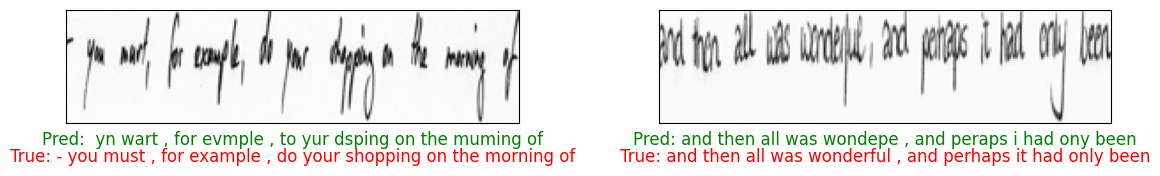

In [15]:
DUMMY_BATCH_SIZE = 2
image_index = np.random.randint(0, x_test.shape[0], size=DUMMY_BATCH_SIZE)
dummy_batch = x_test[image_index]
true_labels = y_test[image_index]

# raw_preds = copy_model.predict(dummy_batch)
raw_preds = model.predict(dummy_batch)

predictions_text = get_decoded_texts(raw_preds)

# Display images with decoded predictions
fig, axes = plt.subplots(1, DUMMY_BATCH_SIZE, figsize=(12, 8))
if DUMMY_BATCH_SIZE == 1:
    axes = [axes]  # Make it iterable for single subplot

for i in range(DUMMY_BATCH_SIZE):
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    img = dummy_batch[i].squeeze()  # Remove channel dimension
    axes[i].imshow(img, cmap='gray')

    # Display the decoded text
    axes[i].text(0.5, -0.15, f'Pred: {predictions_text[i]}', size=12, color='green',
                horizontalalignment='center', verticalalignment='center',
                transform=axes[i].transAxes)

    # Display the true label for comparison
    axes[i].text(0.5, -0.3, f'True: {true_labels[i]}', size=12, color='red',
                horizontalalignment='center', verticalalignment='center',
                transform=axes[i].transAxes)

plt.tight_layout()
plt.show()


Predict frontend image

In [16]:
from PIL import Image
import os

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 256, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 256, 64)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 256, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 256, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 256, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 256, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 256, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 256, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 256, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 256, 256)   │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 256, 256)   │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 256, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 256, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 256, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 256, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 256, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 256, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 256, 2048)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 256, 1024)      │     2,098,176 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256, 1024)      │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256, 1024)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256, 512)       │     2,623,48

 Total params: 7,895,376 (30.12 MB)

 Trainable params: 7,891,408 (30.10 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [28]:
base_dir = './words'
char_images = []
predictions = []

# go through each folder in './words'
for word_folder in sorted(os.listdir(base_dir)):
    folder_path = os.path.join(base_dir, word_folder)

    if not os.path.isdir(folder_path):
        continue

    # Load all character images (sorted by name order)
    image_files = sorted(os.listdir(folder_path))

    word_prediction = []

    if folder_path != "./words/c_chris":
        continue

    for img_file in image_files:
        img_path = os.path.join(folder_path, img_file)

        user_handwriting_image = Image.open(img_path).convert('L').resize((COLS_IMG, ROWS_IMG))
        img_arr = np.array(user_handwriting_image)
        img_arr = img_arr.reshape(1, ROWS_IMG, COLS_IMG, 1)  # Add batch and channel dimensions
        img_arr = img_arr.astype("float32") / 255.0

        user_raw_pred = model.predict(img_arr)

        user_pred_text = get_decoded_texts(user_raw_pred)[0]

        word_prediction.append(user_pred_text)

        '''
        plt.figure(figsize=(10, 3))
        plt.imshow(img_arr[0].squeeze(), cmap='gray')
        plt.title(f"Prediction: {user_pred_text[0]}")
        plt.axis('off')
        plt.show()
        '''

    cleaned_word = ''.join(c.strip() for c in word_prediction)
    predictions.append([folder_path, word_prediction])



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step


In [29]:
from pprint import pprint

pprint(predictions)

[['./words/c_chris',
  ['4 nmiun',
   ' inge  n',
   'yhnnnn',
   't unn',
   'uer ',
   '   nn',
   '  rn',
   '  t',
   'lu',
   '  ']]]
